In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [20]:
df= pd.read_csv('/online_retail.csv', encoding='latin1')

In [21]:
print(df.shape)
df.head()
df.describe()
df.info()


(541910, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [22]:
df.drop_duplicates(inplace=True)

# Remove rows with missing values
df.dropna(inplace=True)

# Convert the necessary columns to the appropriate data types if needed
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d-%m-%Y %H:%M')

# Drop any irrelevant columns if necessary (e.g., 'Country' if not needed)
df = df.drop(['Country'], axis=1)

In [33]:
# Create a 'TotalPrice' column
df['TotalPrice'] = df['Quantity'] * df['Price']

# Group by CustomerID to get the total amount spent, number of orders, and average price
customer_df = df.groupby('Customer ID').agg({
    'TotalPrice': 'sum',
    'Invoice': 'nunique',
    'Quantity': 'sum'
}).rename(columns={
    'TotalPrice': 'TotalSpent',
    'Invoice': 'NumOrders', # Corrected: removed trailing space
    'Quantity': 'TotalQuantity'
})

# Reset index
customer_df = customer_df.reset_index()

# Display the customer_df
customer_df.head()

,Customer ID,TotalSpent,NumOrders,TotalQuantity
0,12346.0,0.00,2,0
1,12347.0,4310.00,7,2458
2,12348.0,1797.24,4,2341
3,12349.0,1757.55,1,631
4,12350.0,334.40,1,197


In [24]:
customer_df.columns

Index(['Customer ID', 'TotalSpent', 'NumOrders ', 'TotalQuantity'], dtype='object')

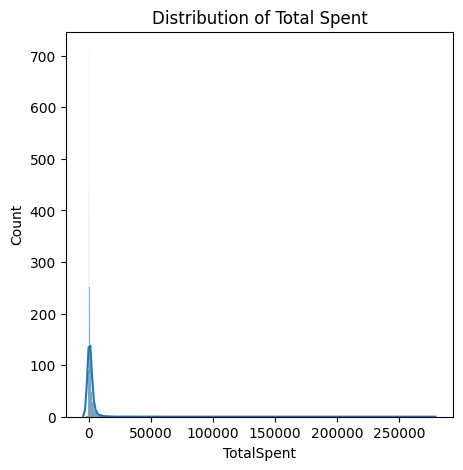

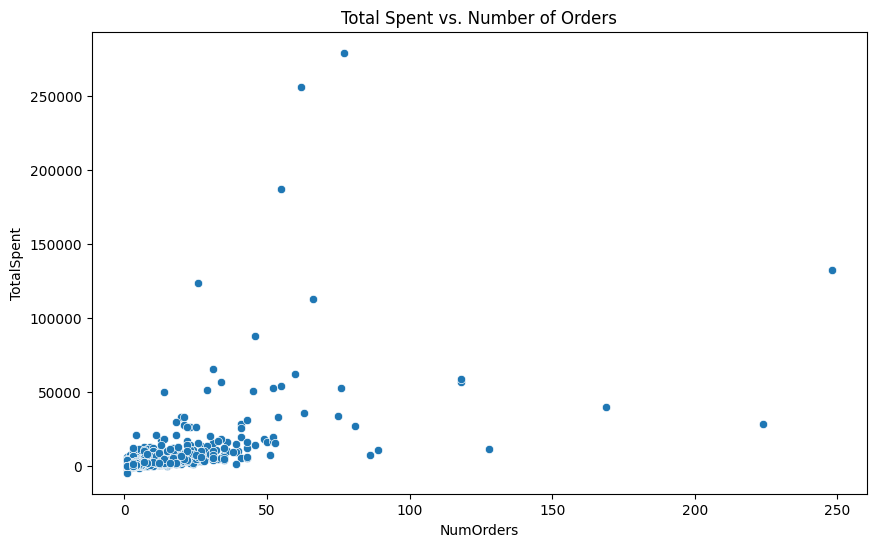

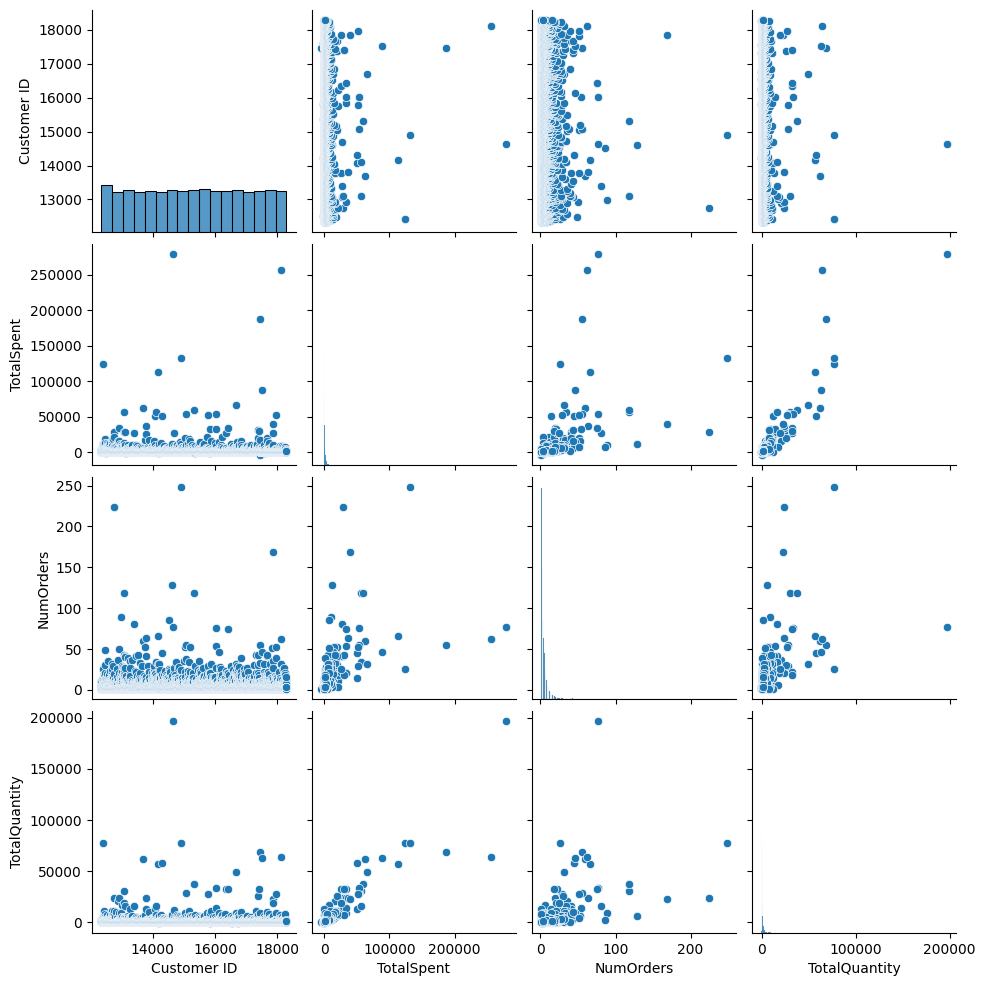

In [35]:
# Clean column names by stripping whitespace
customer_df.columns = customer_df.columns.str.strip()

plt.figure(figsize=(5, 5))
sns.histplot(customer_df['TotalSpent'], kde=True)
plt.title('Distribution of Total Spent')
plt.show()

# Plot the relationship between TotalSpent and NumOrders
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_df, x='NumOrders', y='TotalSpent') # Use the cleaned column name and 'data' parameter
plt.title('Total Spent vs. Number of Orders')
plt.show()

# Pairplot to see relationships between features
sns.pairplot(customer_df)
plt.show()

In [39]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Normalize the data
scaled_features = scaler.fit_transform(customer_df[['TotalSpent', 'NumOrders', 'TotalQuantity']])

# Convert scaled features back to DataFrame
scaled_data = pd.DataFrame(scaled_features, columns=['TotalSpent', 'NumOrders', 'TotalQuantity'])

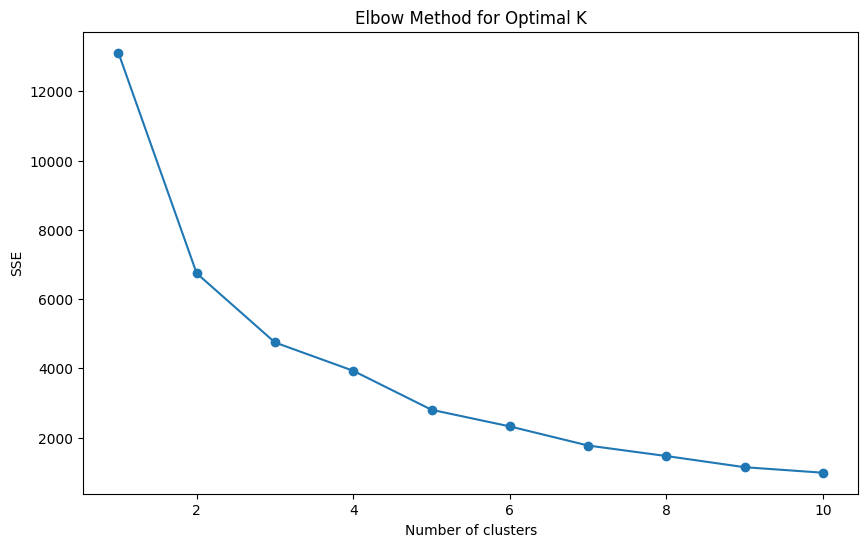

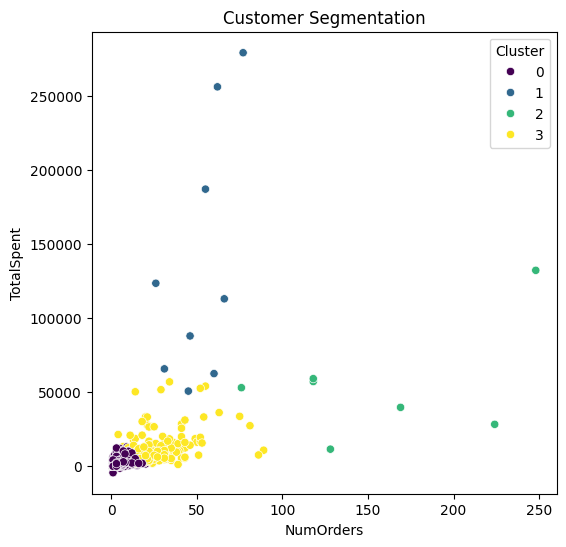

In [42]:
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    sse.append(kmeans.inertia_)

# Plot the elbow method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

# Apply K-Means with the optimal number of clusters (e.g., 4 clusters)
kmeans = KMeans(n_clusters=4, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(scaled_data)

# Visualize the clusters
plt.figure(figsize=(6, 6))
sns.scatterplot(data=customer_df, x='NumOrders', y='TotalSpent', hue='Cluster', palette='viridis')
plt.title('Customer Segmentation')
plt.show()

In [45]:
cluster_summary = customer_df.groupby('Cluster').agg({
    'TotalSpent': 'mean',
    'NumOrders': 'mean',
    'TotalQuantity': 'mean',
    'Customer ID': 'count'
}).rename(columns={'Customer ID': 'NumCustomers'})

# Display the cluster summary
cluster_summary

,TotalSpent,NumOrders,TotalQuantity,NumCustomers
Cluster,,,,
0,1064.423777,3.669639,642.215904,4150
1,136417.795556,52.000000,77369.111111,9
2,54591.671429,154.428571,33074.428571,7
3,10928.528592,26.271845,6309.771845,206
